# Model Development — Fake News Detection
## WELFake Dataset
**Name:** Pulindu Pasanjith  
**Models:** Logistic Regression (ML) and LSTM (DL)  
**Goal:** Train and evaluate my two assigned models using the features saved in Notebook 3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import scipy.sparse
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Input

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1. Load Saved Features from Notebook 3
Everything here was already computed and saved — no re-running preprocessing or feature engineering.

In [2]:
X_train_tfidf = scipy.sparse.load_npz('../models/X_train_tfidf.npz')
X_test_tfidf = scipy.sparse.load_npz('../models/X_test_tfidf.npz')
y_train = np.load('../models/y_train.npy')
y_test = np.load('../models/y_test.npy')

with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

print("✅ TF-IDF features loaded!")
print("Training matrix:", X_train_tfidf.shape)
print("Testing matrix:", X_test_tfidf.shape)

✅ TF-IDF features loaded!
Training matrix: (57632, 50000)
Testing matrix: (14409, 50000)


In [3]:
X_train_pad = np.load('../models/X_train_pad.npy')
X_test_pad = np.load('../models/X_test_pad.npy')

with open('../models/lstm_tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

VOCAB_SIZE = 30000
MAX_LENGTH = 500

print("✅ LSTM sequences loaded!")
print("Training sequences:", X_train_pad.shape)

✅ LSTM sequences loaded!
Training sequences: (57632, 500)


## 2. Model 1 — Logistic Regression (ML Model)
Predicts a probability (0–1) that an article is "Real" (label=1), using the TF-IDF matrix directly.

In [4]:
log_reg = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
log_reg.fit(X_train_tfidf, y_train)

print("✅ Logistic Regression trained!")

✅ Logistic Regression trained!


In [5]:
y_pred_lr = log_reg.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print("\n", classification_report(y_test, y_pred_lr, target_names=['Fake', 'Real']))

Accuracy:  0.9579
Precision: 0.9536
Recall:    0.9651
F1-Score:  0.9593

               precision    recall  f1-score   support

        Fake       0.96      0.95      0.96      7006
        Real       0.95      0.97      0.96      7403

    accuracy                           0.96     14409
   macro avg       0.96      0.96      0.96     14409
weighted avg       0.96      0.96      0.96     14409



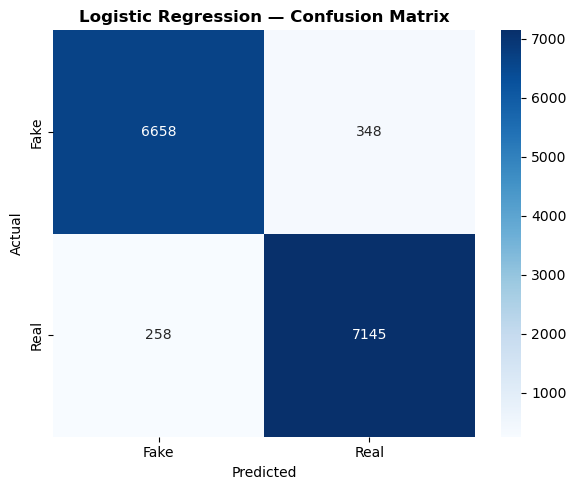

In [6]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../screenshots/07_lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
with open('../models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)

print("✅ Logistic Regression model saved!")

✅ Logistic Regression model saved!


## 3. Model 2 — LSTM (DL Model)
Reads the article as a sequence of words, remembering context as it goes — useful since word order matters ("not fake" ≠ "fake").

**Architecture:**
1. Embedding layer — turns word numbers into dense vectors
2. LSTM layer — learns sequential patterns
3. Dropout — prevents overfitting
4. Dense output — single probability (sigmoid) for Real vs Fake

In [8]:
from tensorflow.keras.layers import Input

EMBEDDING_DIM = 128

lstm_model = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 500, 128)            │       3,840,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (None, 500, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,891,521 (14.84 MB)

 Trainable params: 3,891,521 (14.84 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training the LSTM
EarlyStopping halts training once validation loss stops improving — saves time, avoids overfitting. ~58,000 articles on a laptop CPU can take a while per epoch — be patient.

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

print("✅ LSTM training complete!")

Epoch 1/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 446s 544ms/step - accuracy: 0.5832 - loss: 0.6570 - val_accuracy: 0.5590 - val_loss: 0.6670
Epoch 2/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 435s 537ms/step - accuracy: 0.6476 - loss: 0.5821 - val_accuracy: 0.8858 - val_loss: 0.3115
Epoch 3/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 431s 532ms/step - accuracy: 0.9314 - loss: 0.2011 - val_accuracy: 0.9440 - val_loss: 0.1689
Epoch 4/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 456s 562ms/step - accuracy: 0.9666 - loss: 0.1094 - val_accuracy: 0.9084 - val_loss: 0.5150
Epoch 5/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 451s 556ms/step - accuracy: 0.9763 - loss: 0.0799 - val_accuracy: 0.9499 - val_loss: 0.1961
Epoch 6/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 438s 540ms/step - accuracy: 0.9851 - loss: 0.0522 - val_accuracy: 0.9521 - val_loss: 0.1776
✅ LSTM training complete!


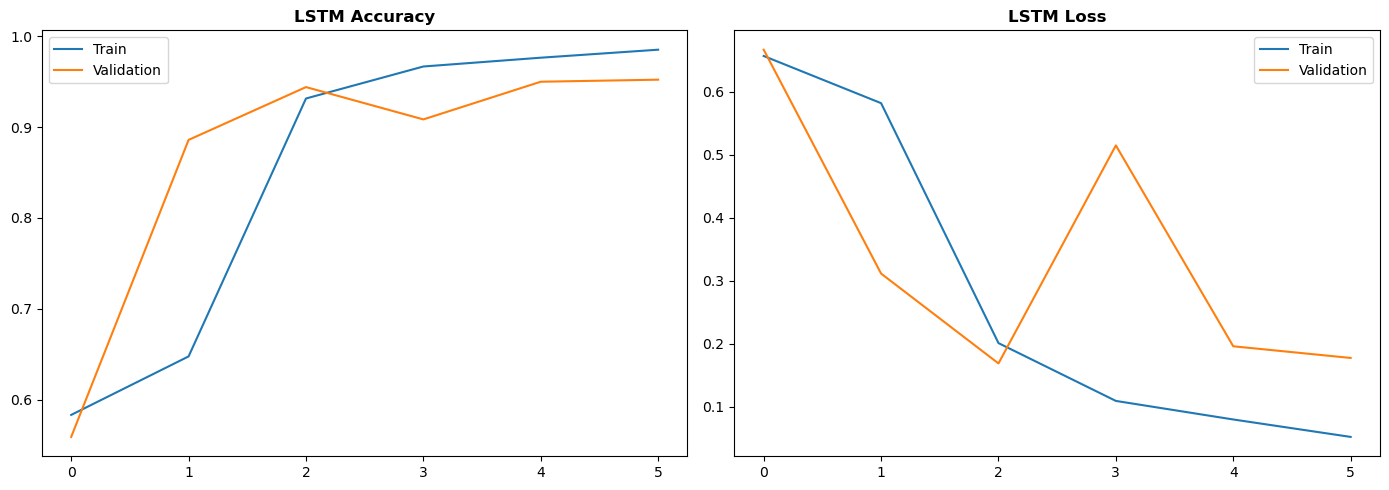

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('LSTM Accuracy', fontweight='bold'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('LSTM Loss', fontweight='bold'); axes[1].legend()

plt.tight_layout()
plt.savefig('../screenshots/08_lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
y_pred_lstm_prob = lstm_model.predict(X_test_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
lstm_precision = precision_score(y_test, y_pred_lstm)
lstm_recall = recall_score(y_test, y_pred_lstm)
lstm_f1 = f1_score(y_test, y_pred_lstm)

print(f"Accuracy:  {lstm_accuracy:.4f}")
print(f"Precision: {lstm_precision:.4f}")
print(f"Recall:    {lstm_recall:.4f}")
print(f"F1-Score:  {lstm_f1:.4f}")
print("\n", classification_report(y_test, y_pred_lstm, target_names=['Fake', 'Real']))

451/451 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step
Accuracy:  0.9397
Precision: 0.9447
Recall:    0.9375
F1-Score:  0.9411

               precision    recall  f1-score   support

        Fake       0.93      0.94      0.94      7006
        Real       0.94      0.94      0.94      7403

    accuracy                           0.94     14409
   macro avg       0.94      0.94      0.94     14409
weighted avg       0.94      0.94      0.94     14409

